# Código humano

## El valor del software

El valor de cualquier sofware viene de la funcionalidad que ofrece cuando se ejecuta, NO viene de su código fuente. Es más, **el código fuente reduce el valor del software porque su mantenimiento implica un costo**.

Para mentener código primero hay que entender lo que hace; por esta razón, hay que **optimizar la organización del código para que su lectura implique el menor esfuerzo posible**.

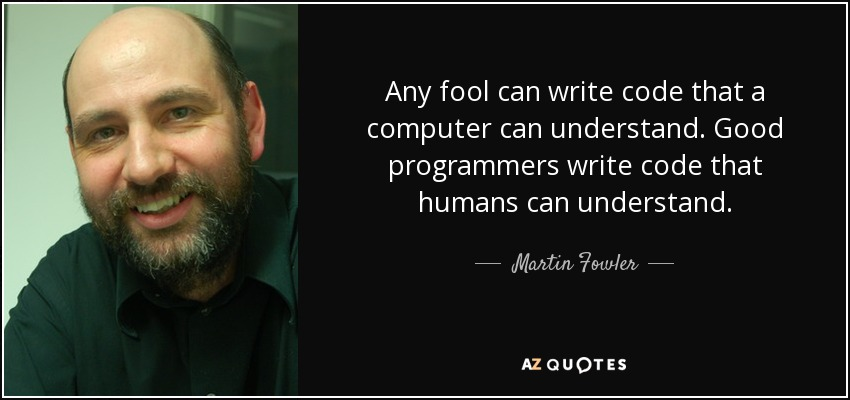

## Lectura de código y memoria de trabajo

El hecho de que la memoria de corto plazo permite retener aproximadamente [7 ítems de información](https://es.wikipedia.org/wiki/El_m%C3%A1gico_n%C3%BAmero_siete,_m%C3%A1s_o_menos_dos) implica que cuando se intenta entender un fragmento de código sólo podemos hacer seguimiento a un número limitado de variables y rutas de ejecución.

Cuando se lee código, llegamos a conclusiones basadas únicamente en la información activa (visible); es decir, solo [aquello que podemos ver se considera relevante](https://www.linkedin.com/pulse/what-you-see-all-jack-van-der-sanden) para entender código, por ejemplo, difícilmente tendremos en cuenta parámetros de configuración guardados en archivos o valores de variables de entorno.

Escribir código para humanos implica escribir funciones pequeñas e independientes, preferir el enfoque funcional al imperativo, evitar que hayan más de siete items a los cuales se debe prestar atención para entender una función, evitar que la complejidad ciclomática supere determinado umbral, etc.

## Métricas de complejidad de código

- __[Complejidad ciclomática](https://es.wikipedia.org/wiki/Complejidad_ciclom%C3%A1tica)__. Mide el número caminos de ejecución (flujos de control) en una función.
- __[Indice de mantenibilidad](https://sourcery.ai/blog/maintainability-index/)__. Resulta de una combinación de métricas que generan un valor entre 0 - 100 (Más cerca a 100 => más mantenible).
- __[Complejidad cognitiva](https://www.sonarsource.com/docs/CognitiveComplexity.pdf)__. Mide la dificultad relativa para entender funciones o clases.
- **Flor hexagonal**. Permite visualizar el número de elementos de los cuales hay estar pendientes para entender una función. Por ejemplo, el número de flujos de control o la cantidad de objetos activos.

**Complejidad ciclomática:**

```
    public async Task<ActionResult> Post(ReservationDto dto)
    {
        if (dto is null)
            throw new ArgumentNullException(nameof(dto));
        if (!DateTime.TryParse(dto.At, out var d))
            return new BadRequestResult();
        if (dto.Email is null)
            return new BadRequestResult();
        if (dto.Quantity < 1)
            return new BadRequestResult();

        var reservations =
            await Repository.ReadReservations(d).ConfigureAwait(false);
        int reservedSeats = reservations.Sum(r => r.Quantity);
        if (10 < reservedSeats + dto.Quantity)
            return new StatusCodeResult(
                StatusCodes.Status500InternalServerError);

        var r =
            new Reservation(d, dto.Email, dto.Name ?? "", dto.Quantity);
        await Repository.Create(r).ConfigureAwait(false);

        return new NoContentResult();
        }
```

Toda función tiene al menos un flujo de control por lo que la complejidad ciclomática mínima es 1. Entonces, comenzando en 1 e incrementamos en 1 por cada ```if``` o ```for``` (la idea es contar cada bifurcación y repetición).

**Cuál es la complejidad ciclomática del código?**


En el caso de la función de ejemplo, la complejidad ciclomática es 7:
- Iniciamos en 1
- Hay 5 ```if```, +5
- El operador ```??``` implica una bifurcación, +1

**Flor hexagonal: flujos de control**

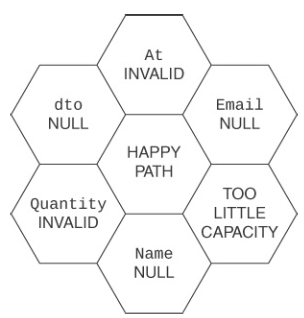


**Flor hexagonal: objetos activos**
  
```
    private void ConfigureRepository(IServiceCollection services)
    {
        var connStr = Configuration.GetConnectionString("Restaurant");
        services.AddSingleton<IReservationsRepository>(sp =>
        {
            var logger =
                sp.GetService<ILogger<LoggingReservationsRepository>>();
            var postOffice = sp.GetService<IPostOffice>();
            return new EmailingReservationsRepository(
                postOffice,
                new LoggingReservationsRepository(
                    logger,
                    new SqlReservationsRepository(connStr)));
        });
    }
```

Complejidad ciclomática 1. Objetos activos 6:


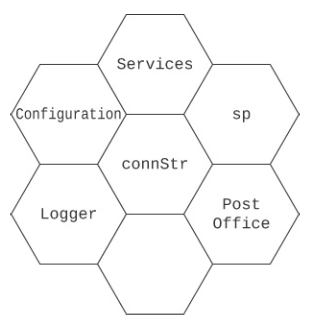


## Buenas prácticas para escribir código para humanos

Entre las prácticas más efectivas para escribir código humano podemos citar:
- **Separación comando/consulta**. Cada función debe ser un comando que realice una acción o una consulta que devuelva datos, pero no ambos.
- **Aplicar cambios exclusivamente orientados a mejorar la legibilidad** - [Refactoring](https://refactoring.guru/refactoring/catalog)
- **Programación por pares**. Dos programadores **colaborando** en tiempo real en el mismo problema.
    - Aunque no es para todos, es una forma muy efectiva de transferir conocimiento y lograr la propiedad colectiva del código.
    - Hay varios [estilos de programación por pares](https://martinfowler.com/articles/on-pair-programming.html).
        - Driver and Navigator (revisión en tiempo real)
        - Ping Pong (TDD)
        - Strong-Style Pairing (transferencia de conocimiento)
        - Desarrollo por pares (la interacción inicia antes de programar)
    
- **Revisión de código**. La pregunta más importante que debe responderse el revisor es "¿estaría dispuesto a mantener este código? (Se asume que el código ha sido escrito para satisfacer un requerimiento)
    - ¿El código es legible? y [preguntas similares](https://twitter.com/housecor/status/1115959687332159490).
    - El autor NO debe involucrarse en la revisión.
    - El objetivo es llegar a un acuerdo sobre como debería organizarse el código.
    - Cuando el revisor rechaza el código, debe incluir sugerencias de mejora explicando por qué aplicarlas mejoraría el código (puede incluir ejemplos, enlaces, realizar un reunión, etc.)
    - El autor puede explicar por qué se hicieron las cosas de cierta manera.
    - Todos son autores y revisores

## Niveles de abtracción

Además de ayudar a reducir la duplicación de código, las funciones deben servir para ocultar detalles de implementación de manera tal que existan funciones en las que el revisor tenga una idea clara de la extrategia de solución sin estar obligado a leer los detalles de su implementación.

Usualmente, estos métodos *ocultan* estructuras de control (```for```, ```if```, ```while```), verificación de expresiones regulares o manipulación secuencias en funciones con nombres que describen claramente la intención detrás del código.

## Herramientas para obtener métricas de complejidad de código

- [Radon](https://radon.readthedocs.io/en/latest/index.html) - Radon is a Python tool which computes various code metrics
- [python-radon](https://marketplace.visualstudio.com/items?itemName=ChristianDein.python-radon) - Visual Studio Code extension

**Referencia rápida - Radon**

[Instalar radon](https://anaconda.org/conda-forge/radon):

```
conda install -c conda-forge radon
```

Obtener la complejidad ciclomática de un archivo ```*.py```

In [ ]:
# Comentar antes de probar radon con el notebook
# https://radon.readthedocs.io/en/latest/commandline.html
#!radon cc cyclomatic_example.py -s

- ```F``` señala una función, ```M``` un método y ```C``` una clase.
- ```get_odd_numbers``` es el nombre de la función.
- ```3``` es la línea en la que comienza la función.
- ```A``` es el grado de complejidad que va desde ```A``` hasta ```F```. ```A``` es el mejor grado, supone una complejidad baja.
- El número entre paréntesis, ```3```, es la complejidad ciclomática.

Enlace a la [documentación del comando *cc*](https://radon.readthedocs.io/en/latest/commandline.html#the-cc-command)

__[radon con jupyter notebooks](https://radon.readthedocs.io/en/latest/commandline.html#usage-with-jupyter-notebooks)__

```
radon cc --include-ipynb 01_python/04_funciones_y_codigo_limpio/05_código_para_humanos_parte_1_de_2.ipynb
```

```
radon cc --include-ipynb 01_python/04_funciones_y_codigo_limpio/ -s
```

In [ ]:
#Código que está fuera de una función es ignorado por radon
numbers = [1,2,3,4,5,6,7,8]
odd_numbers = []
for item in numbers:
  if item % 2 == 1:
    odd_numbers.append(item)
print(odd_numbers)

In [ ]:
def get_odd_numbers(numbers):
    odd_numbers = []
    for item in numbers:
      if item % 2 == 1:
        odd_numbers.append(item)

    return odd_numbers


## Referencias

- [What Is Clean Code? – In Quotes](https://dzone.com/articles/what-clean-code-%E2%80%93-quotes)
- [Refactoring.com](https://refactoring.com/catalog/)